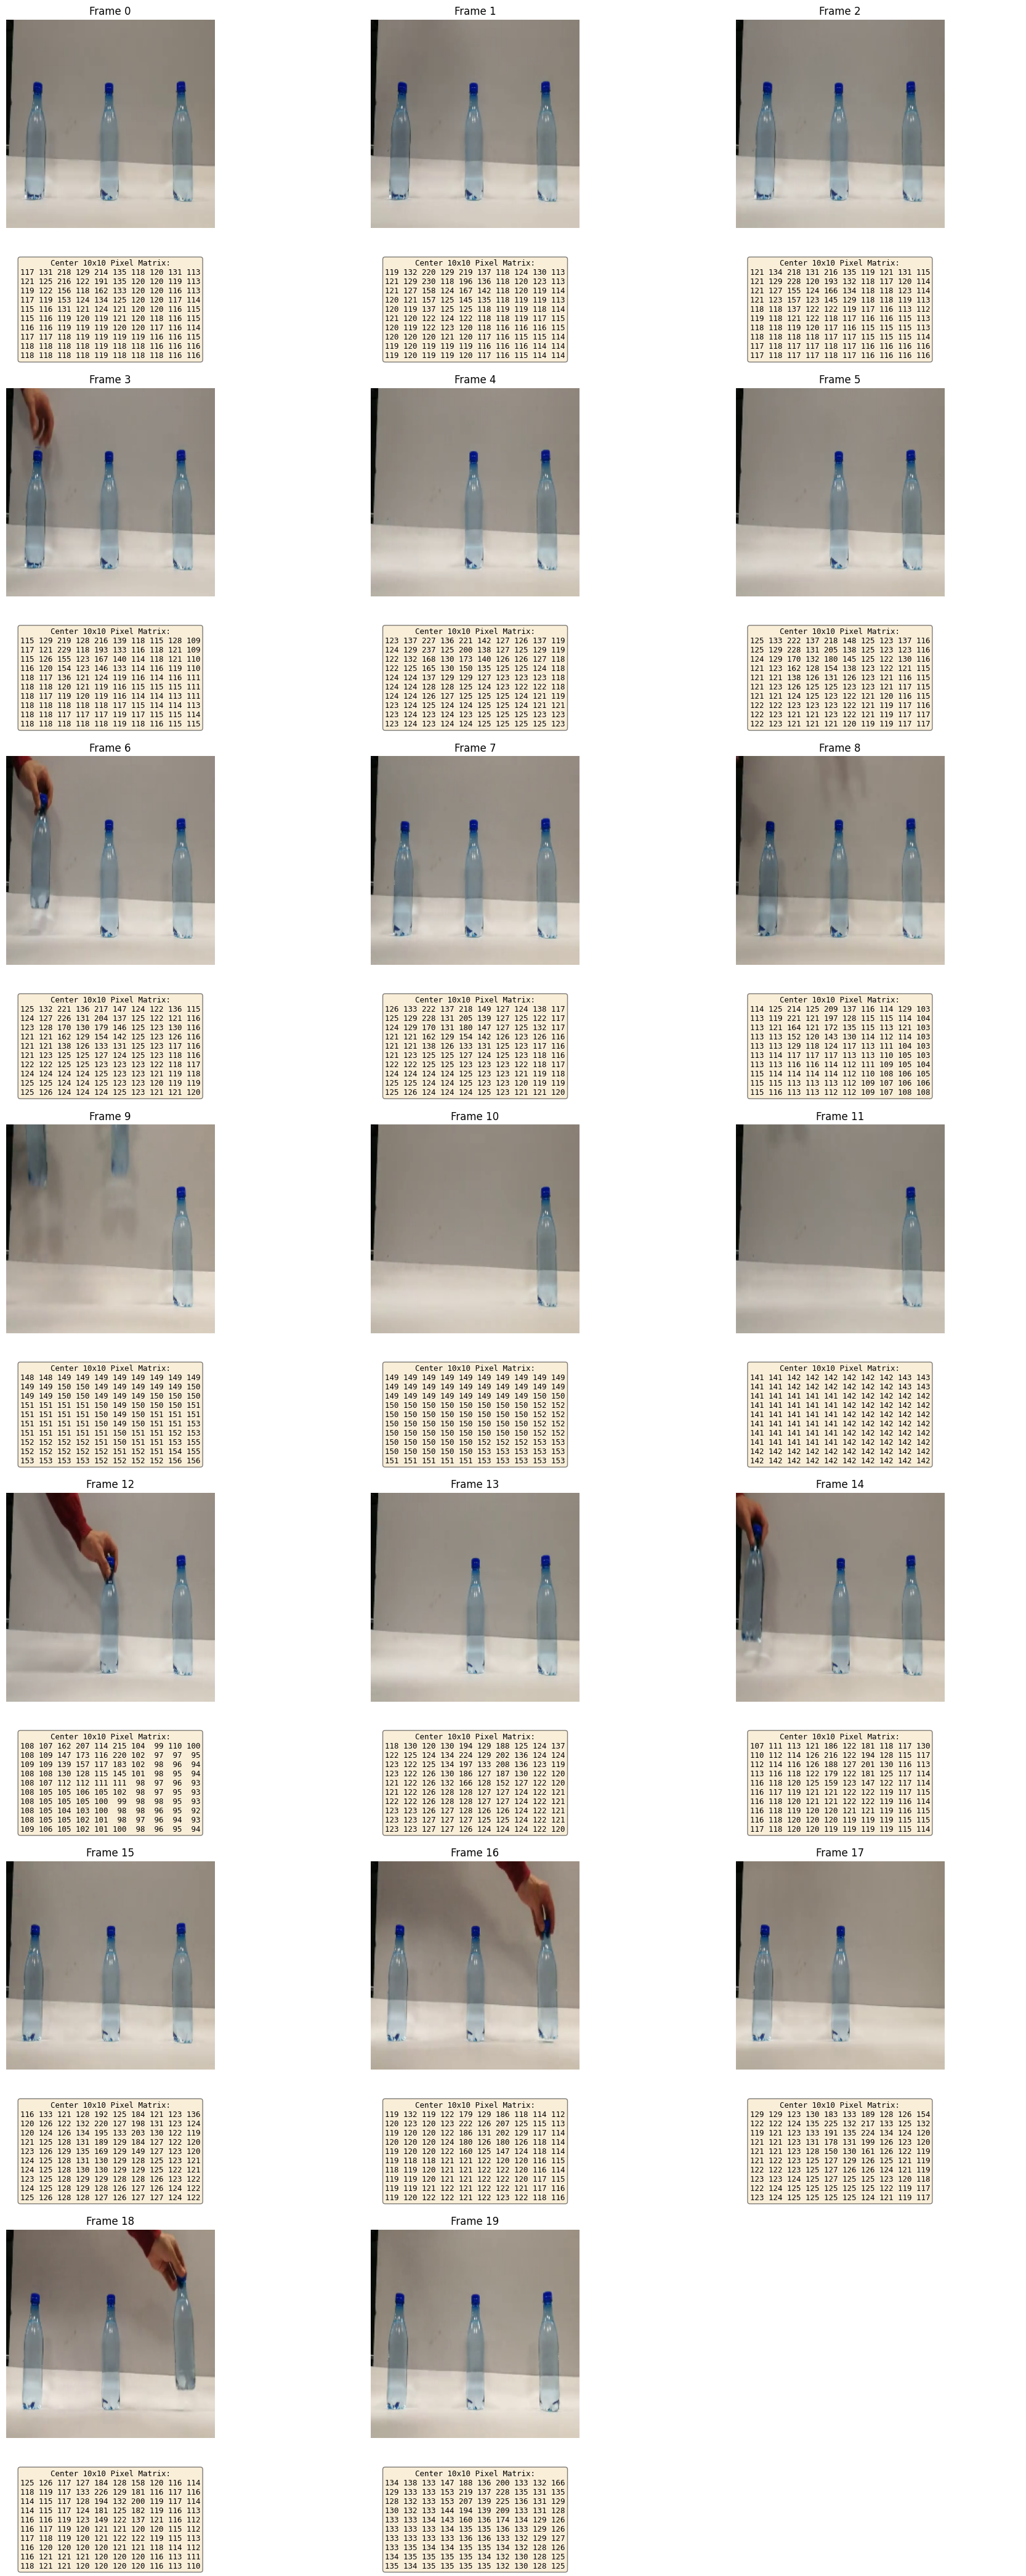

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

      FINAL PREDICTIONS
water_bottle   : 41.52%
pop_bottle     : 6.58%
wine_bottle    : 3.50%
beer_bottle    : 3.47%
perfume        : 3.12%

Final Prediction: water_bottle


In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total_frames // max_frames) if total_frames > 0 else 1
    count = 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        count += 1
        if len(frames) >= max_frames: break

    cap.release()
    return np.array(frames)

def classify_video(video_path):
    frames = extract_frames(video_path)
    if len(frames) == 0: return

    cols = 3 # Reduced columns to make space for the text matrix
    rows = (len(frames) + cols - 1) // cols

    # Increase height to accommodate the text blocks
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = axes.flatten()

    for i in range(len(axes)):
        if i < len(frames):
            frame = frames[i]

            # 1. Display Frame
            axes[i].imshow(frame)
            axes[i].set_title(f"Frame {i}")
            axes[i].axis('off')

            # 2. Extract Center 10x10 Matrix (Red Channel)
            # We use the Red channel (0) to represent the intensity
            start, end = 107, 117
            pixel_matrix = frame[start:end, start:end, 0]

            # 3. Format matrix as string and print below the image
            matrix_str = "\n".join([" ".join([f"{val:3}" for val in row]) for row in pixel_matrix])
            axes[i].text(0.5, -0.15, f"Center 10x10 Pixel Matrix:\n{matrix_str}",
                         transform=axes[i].transAxes, fontsize=9,
                         family='monospace', ha='center', va='top',
                         bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # --- Classification ---
    processed_frames = preprocess_input(frames.copy().astype(float))
    predictions = model.predict(processed_frames)
    avg_pred = np.mean(predictions, axis=0)
    top_preds = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)[0]

    print("\n" + "="*30)
    print("      FINAL PREDICTIONS")
    print("="*30)
    for _, label, prob in top_preds:
        print(f"{label:15}: {prob*100:.2f}%")

    print(f"\nFinal Prediction: {top_preds[0][1]}")

# Run the function
video_path = "/content/bottle-detection.mp4"
classify_video(video_path)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import IPython.display as ipd
from tqdm.notebook import tqdm

In [13]:
ipd.Video("/content/bottle-detection.mp4", width=200)

In [14]:
# Load in video capture
import cv2
cap = cv2.VideoCapture('/content/bottle-detection.mp4')

In [15]:
# Total number of frames in video
cap.get(cv2.CAP_PROP_FRAME_COUNT)

1189.0

In [16]:
# Video height and width
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
print(f'Height {height}, Width {width}')

Height 360.0, Width 640.0


In [17]:
# Get frames per second
fps = cap.get(cv2.CAP_PROP_FPS)
print(f'FPS : {fps:0.2f}')

FPS : 29.83


In [18]:
cap.release()

In [20]:
cap = cv2.VideoCapture('/content/bottle-detection.mp4')
ret, img = cap.read()                            #will return TRUE everytime we call this function till we reach the end of the video
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (360, 640, 3)


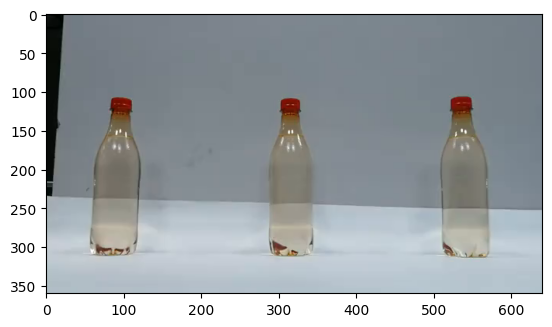

In [21]:
plt.imshow(img)

In [22]:
## Helper function for plotting opencv images in notebook
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

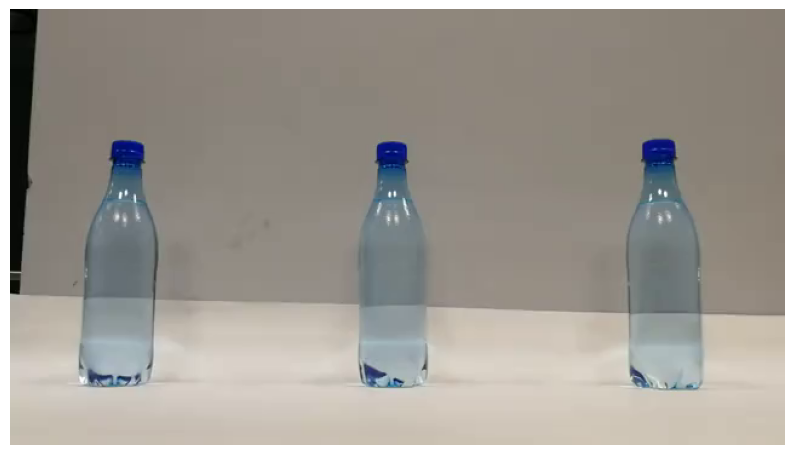

In [23]:
display_cv2_img(img)

In [24]:
cap.release()

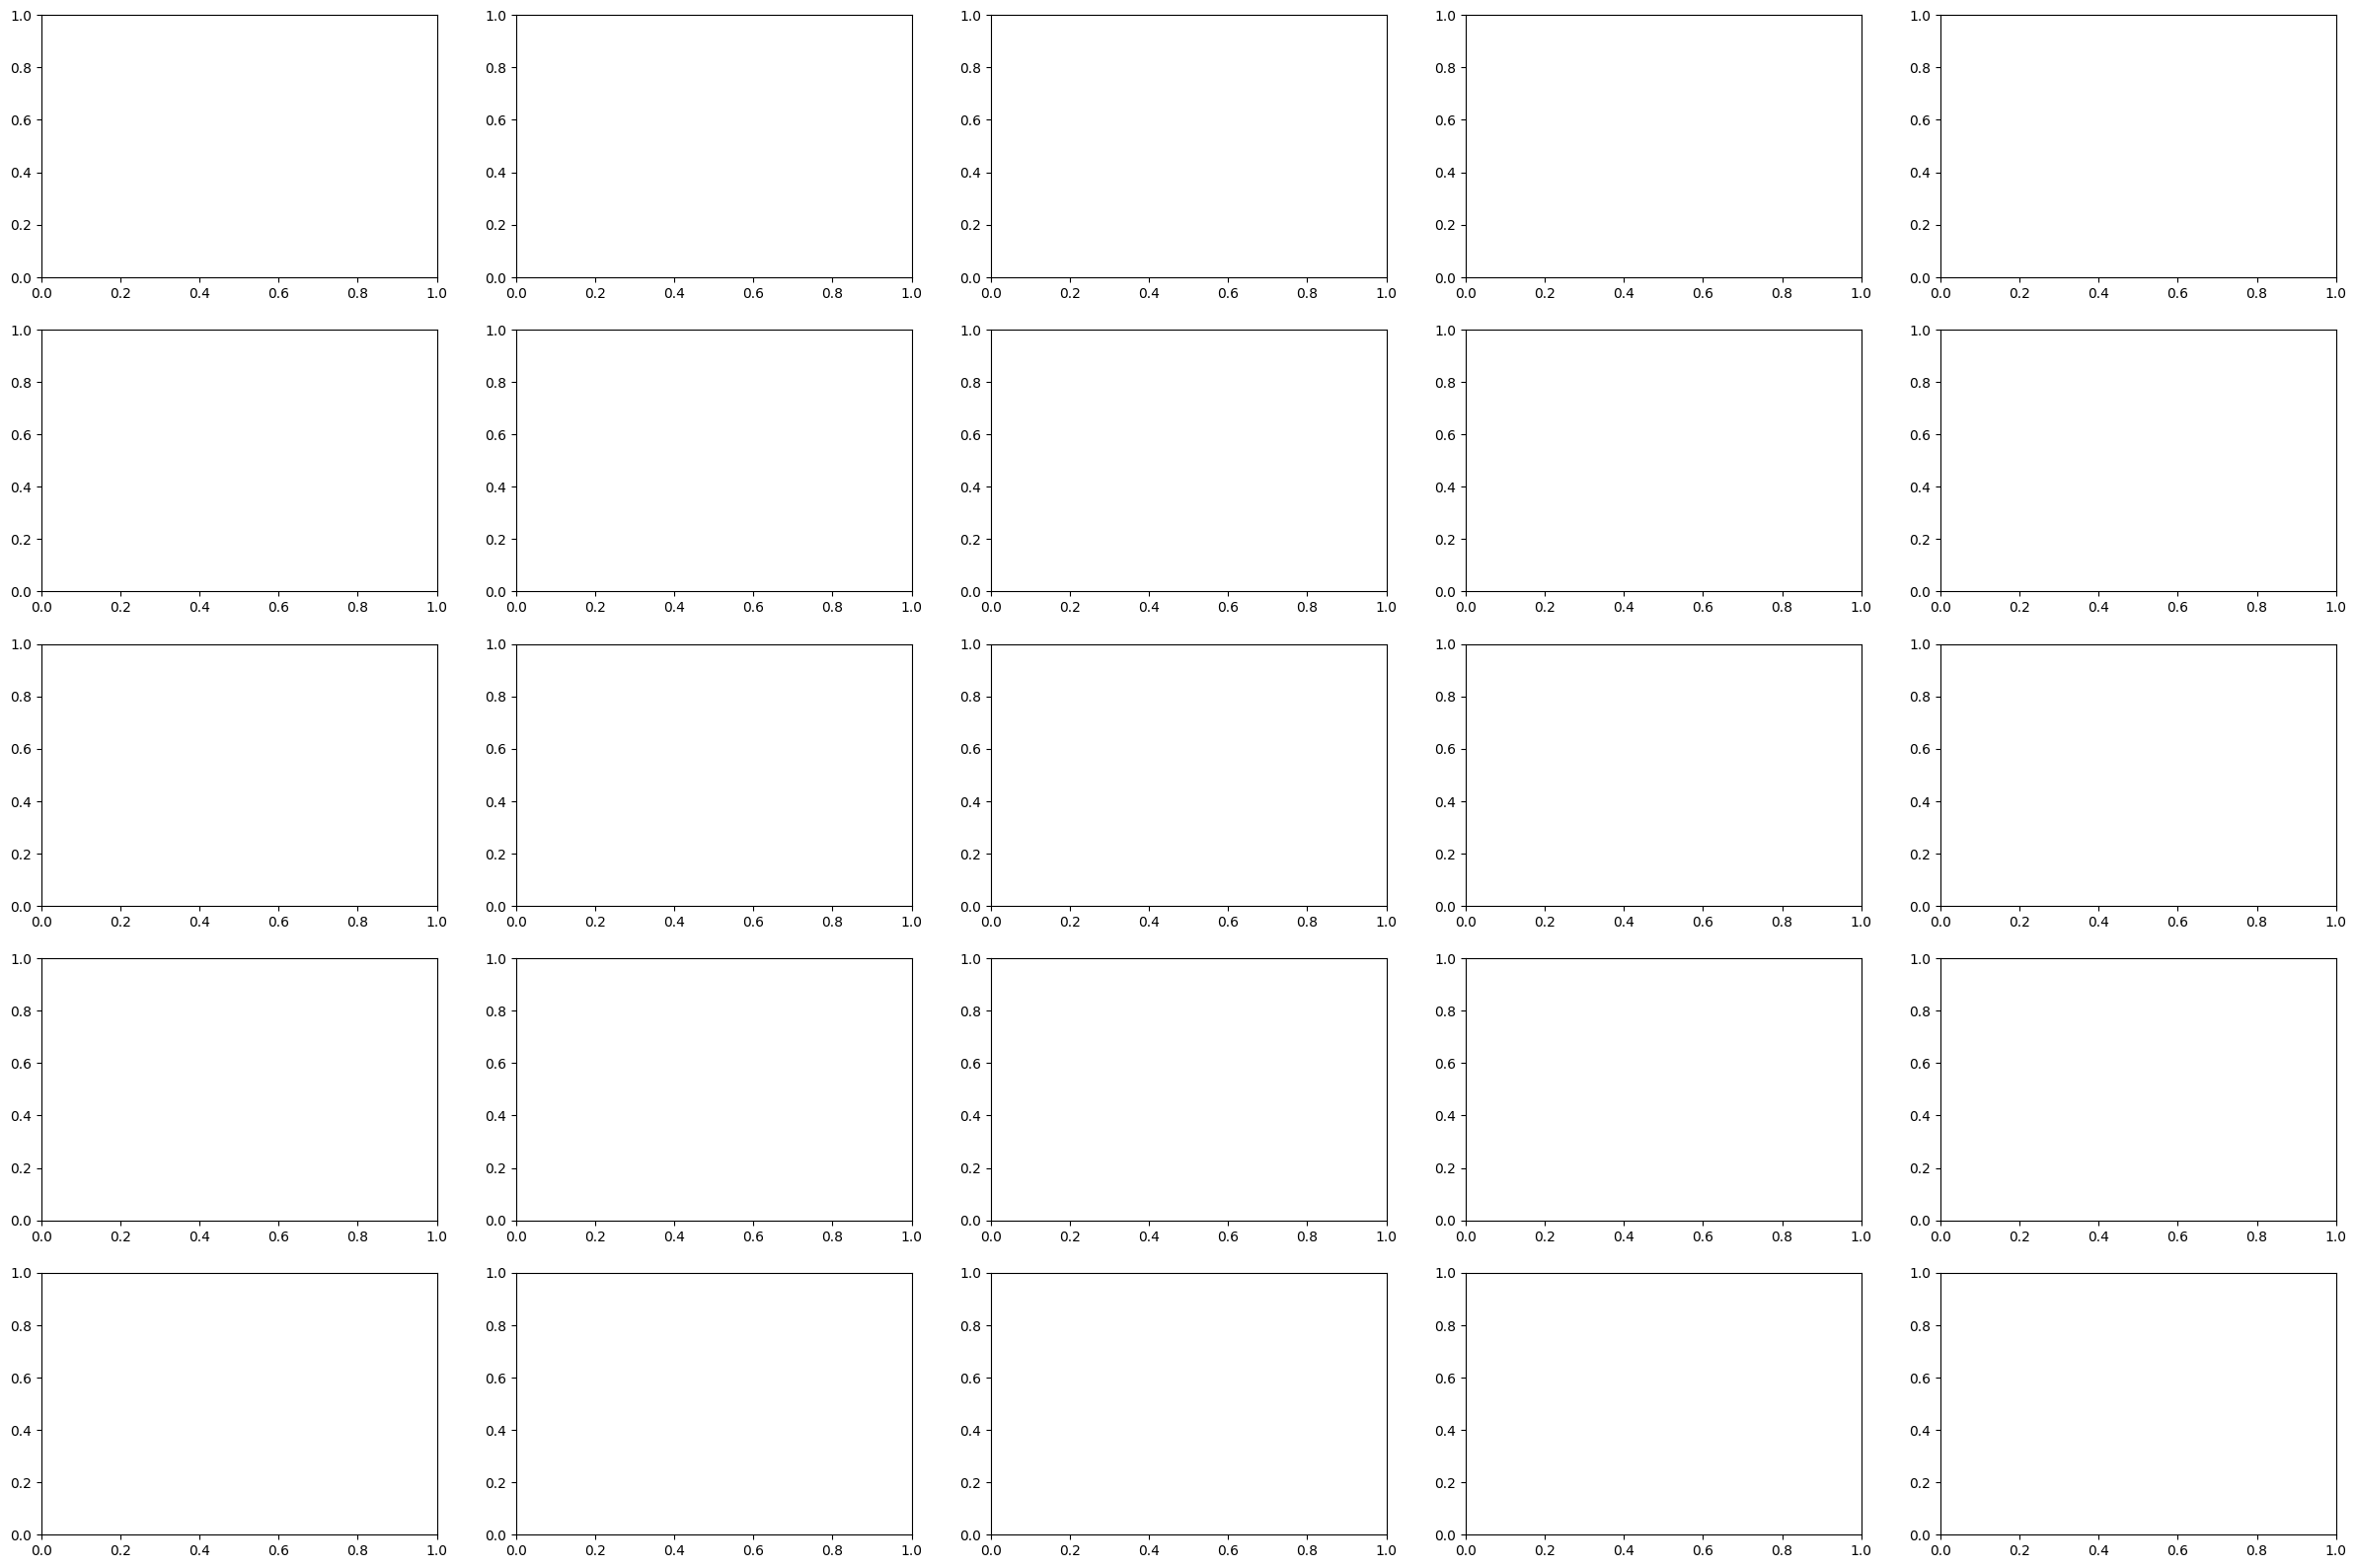

In [25]:
fig, axs = plt.subplots(5, 5, figsize=(30, 20))
plt.show()

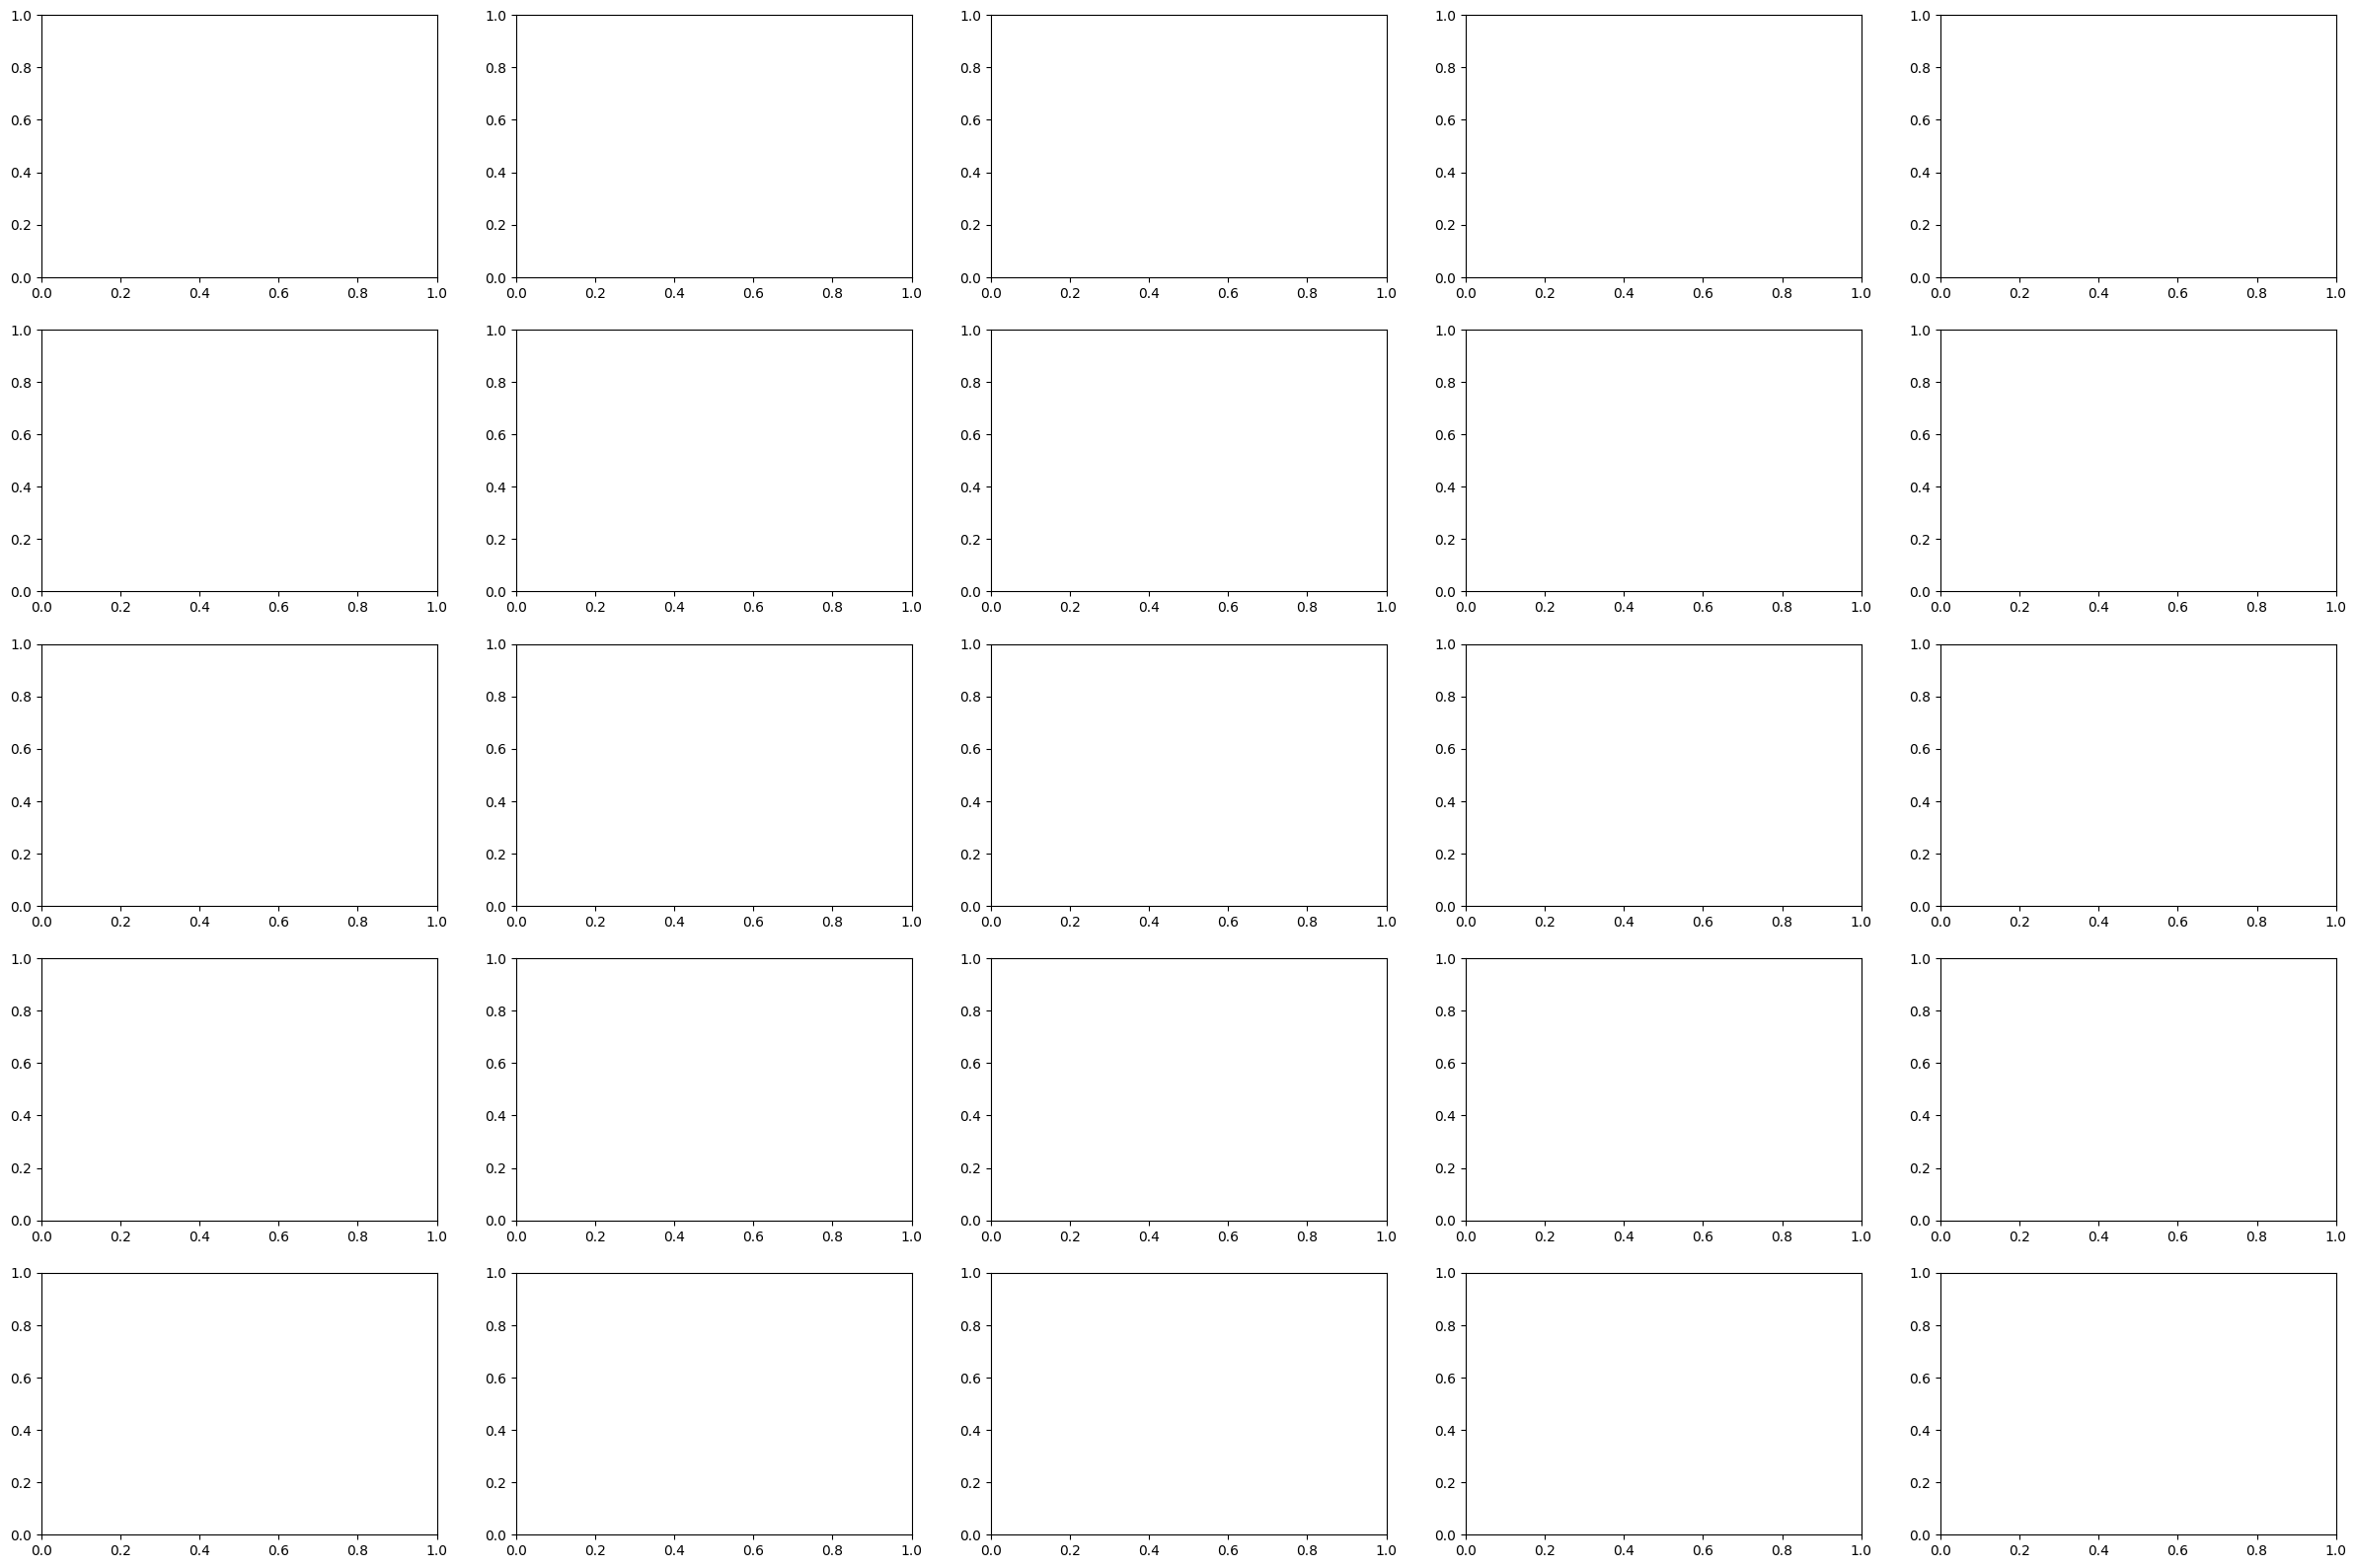

In [26]:
fig, axs = plt.subplots(5, 5, figsize=(30, 20))
axs = axs.flatten()
plt.show()

# Without flatten → 2D grid (row, column)
# With flatten → 1D list (single index)

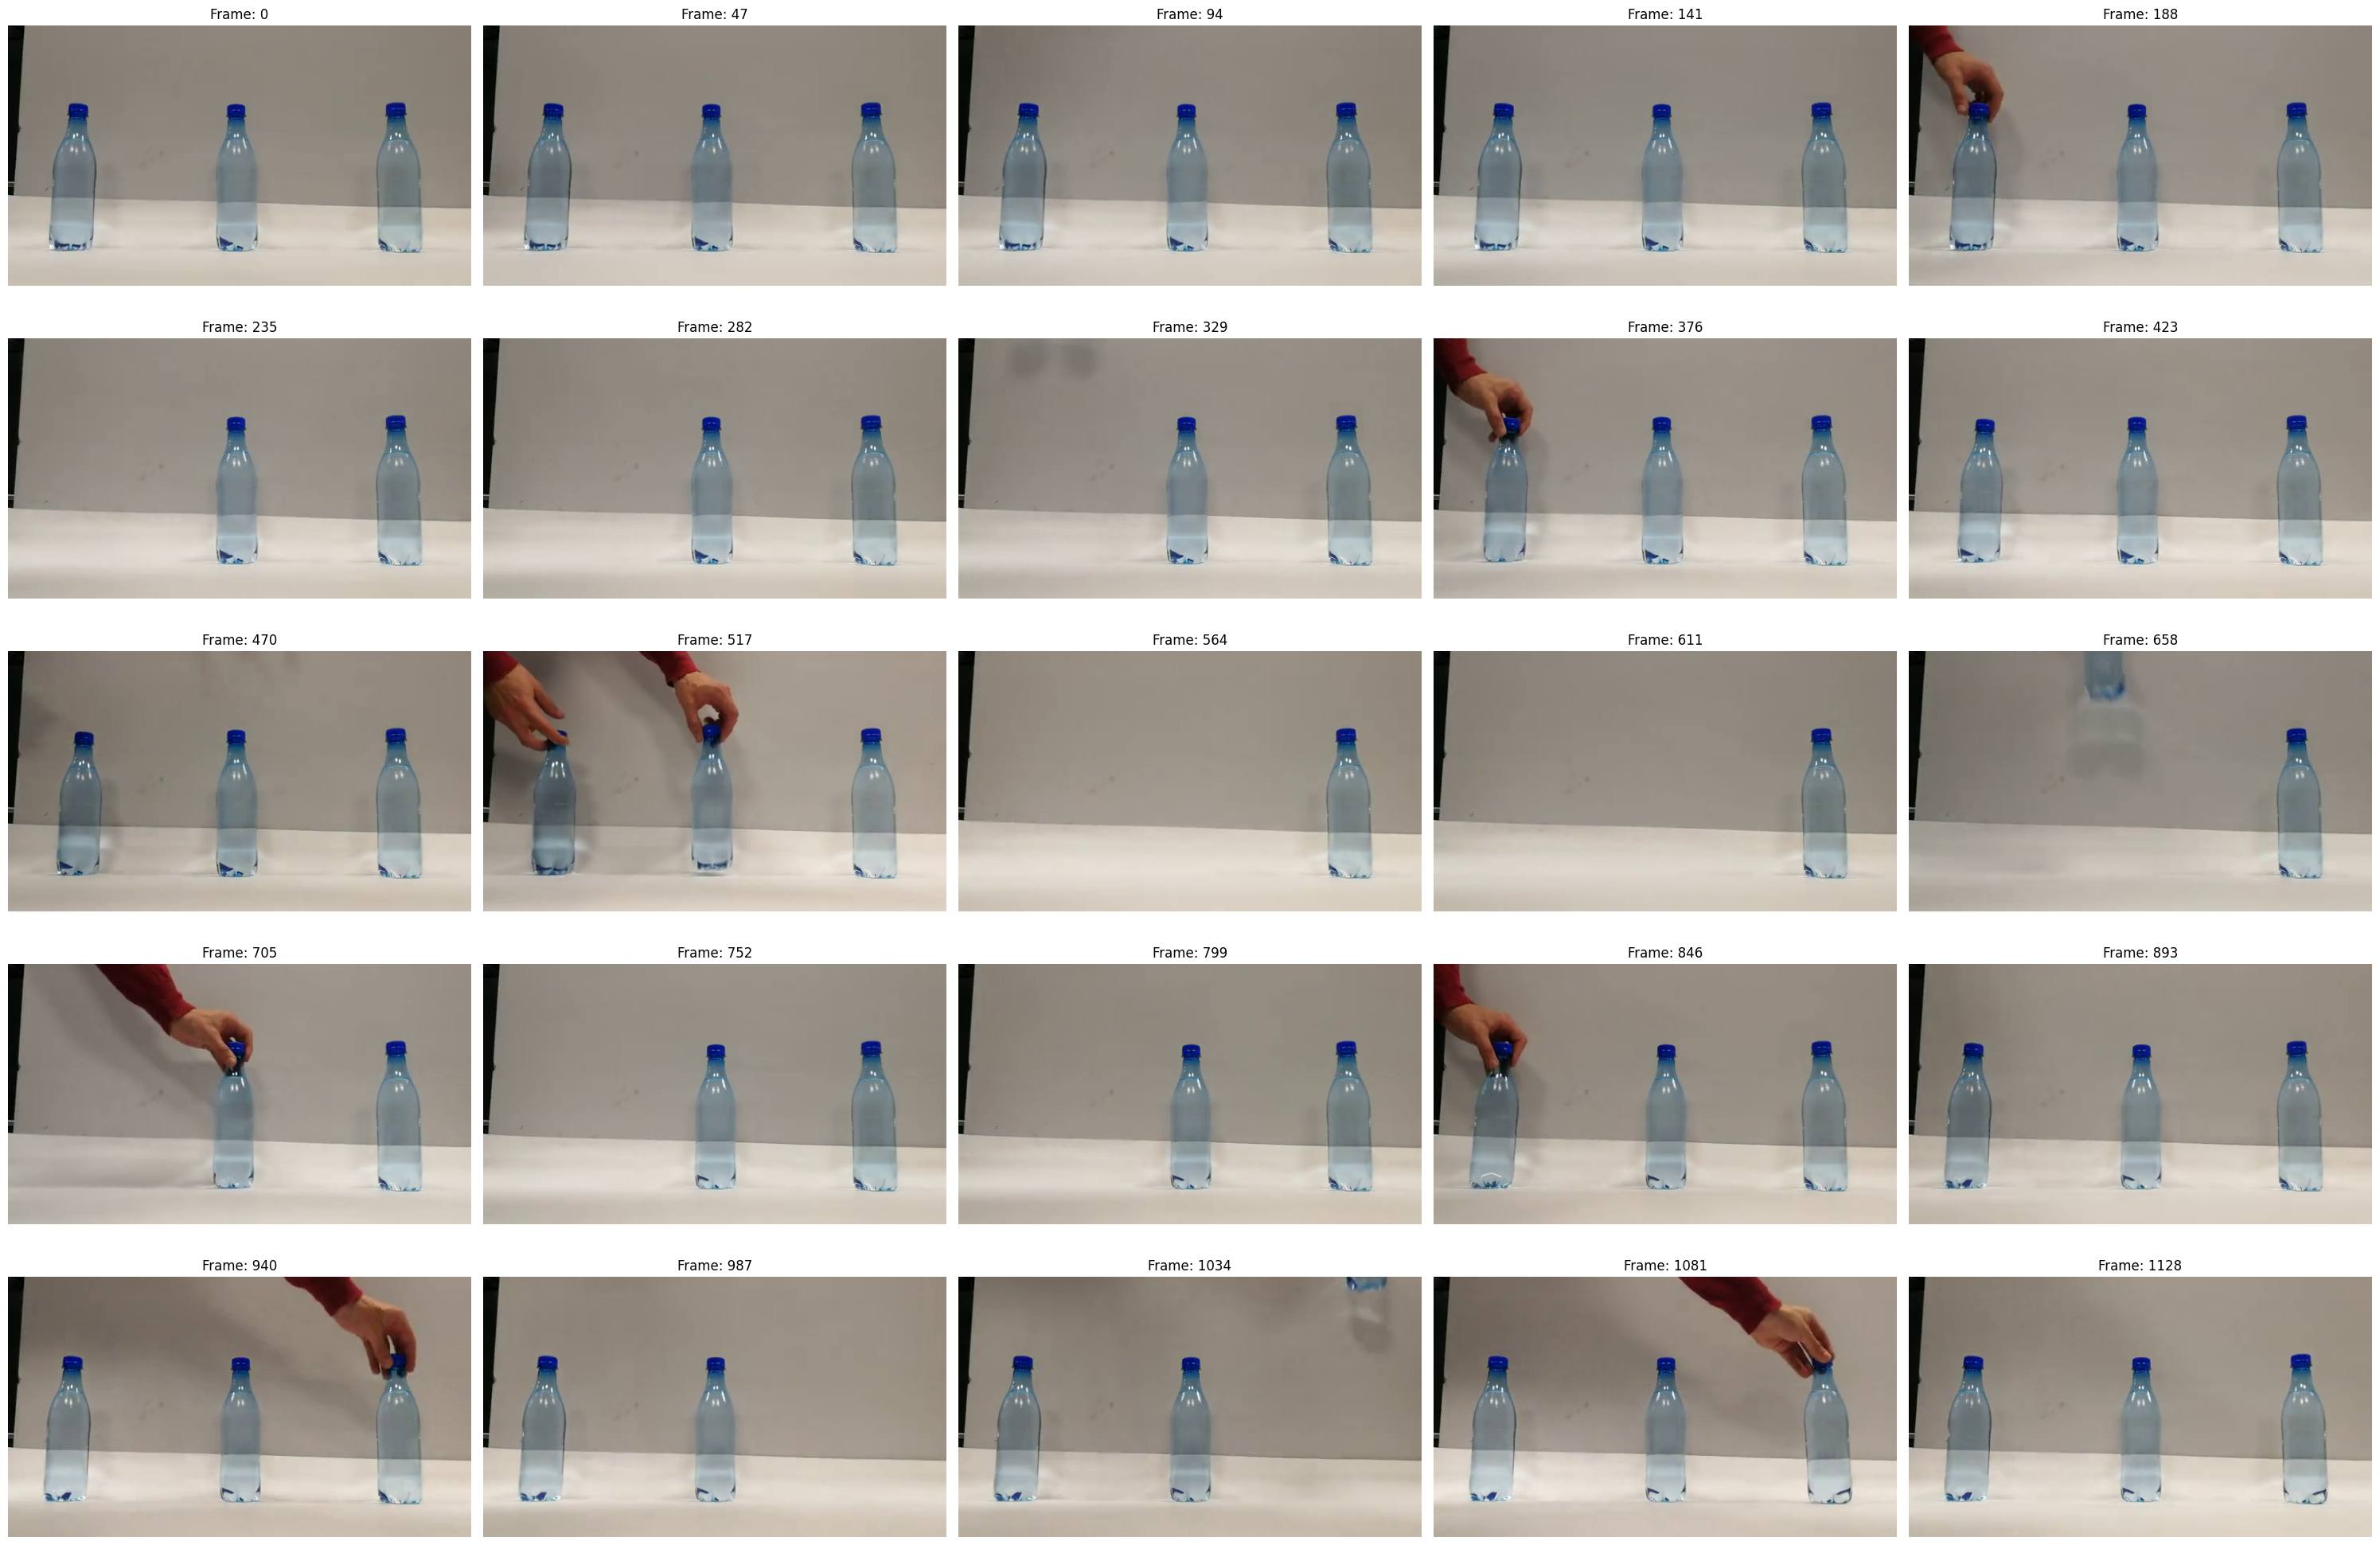

In [29]:
import cv2
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, 5, figsize=(30, 20))
axs = axs.flatten()

cap = cv2.VideoCapture("/content/bottle-detection.mp4")
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Calculate step to get approximately 25 evenly spaced frames
num_frames_to_show = len(axs) # 25 frames for a 5x5 grid
step = max(1, n_frames // num_frames_to_show)

img_idx = 0
for frame_count in range(n_frames):
    ret, img = cap.read()
    if not ret: # Use 'not ret' for cleaner check
        break

    # Display a frame if it's at the calculated step and we haven't filled all subplots
    if frame_count % step == 0 and img_idx < num_frames_to_show:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame_count}')
        axs[img_idx].axis('off')
        img_idx += 1

# Turn off any unused subplots if the video has too few frames
for i in range(img_idx, num_frames_to_show):
    axs[i].axis('off')

plt.tight_layout()
plt.show()
cap.release()